### Fragment length frequency (1 mark) + rescaling (2 marks)

Importing Libraries

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Reading query.bed

In [54]:
fragments = []

with open('query.bed', 'r') as f:

    for line in f:
        cols = line.strip().split('\t')
        fragment_length = int(cols[2]) - int(cols[1])
        fragments.append(fragment_length)

Normalizing fragment lengths

In [55]:
lengths , freq = np.unique(fragments, return_counts=True)
normalized_freq = freq / np.sum(freq)

Plotting normalized fragment length distribution

Text(0.5, 1.0, 'Fragment Length Distribution')

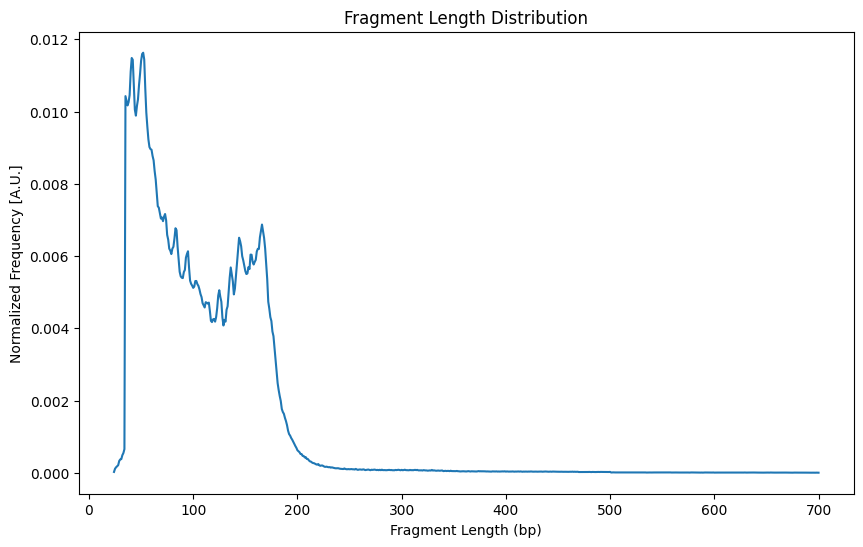

In [56]:
plt.figure(figsize=(10, 6))
plt.plot(lengths, normalized_freq)
plt.xlabel('Fragment Length (bp)')
plt.ylabel('Normalized Frequency [A.U.]')
plt.title('Fragment Length Distribution')

Reading reference.hist

In [57]:
ref_lengths = []
ref_freq = []

with open('reference.hist', 'r') as f:

    for line in f:
        col1 , col2 = map(float, line.strip().split())
        ref_lengths.append(col1)
        ref_freq.append(col2)

reference_lengths = np.array(ref_lengths)
reference_freq = np.array(ref_freq) / np.sum(ref_freq)

Rescaling the Query along with Reference

In [58]:
# Dateframe for query
query_df = pd.DataFrame({
    'Length': lengths,
    'Frequency': freq
})

reference_norm = np.array(ref_freq) / np.sum(ref_freq)

#scale the reference frequencies to match the query total
reference_df = pd.DataFrame({
    'Length': ref_lengths,
    'Frequency': reference_norm * sum(freq) 
})

# Create bins
edges = np.arange(0, 510, 10)
labels = [f"{i}-{i+10}" for i in edges[:-1]]

# Bin the data 
query_df['Bin'] = pd.cut(query_df['Length'], bins=edges, labels=labels, right=False)
reference_df['Bin'] = pd.cut(reference_df['Length'], bins=edges, labels=labels, right=False)

# Count per‑bin frequency
q_counts = query_df.groupby('Bin', observed=True)['Frequency'].sum().reindex(labels, fill_value=0)
r_counts = reference_df.groupby('Bin', observed=True)['Frequency'].sum().reindex(labels, fill_value=0)

# Sample reference down to query counts
sampled_parts = []
for b in labels:
    n_query = int(q_counts[b])
    ref_bin = reference_df[reference_df['Bin'] == b]
    if n_query > 0 and len(ref_bin):
        n_sample = min(n_query, len(ref_bin))
        sampled_parts.append(ref_bin.sample(n=n_sample, random_state=42))

sampled_reference_df = pd.concat(sampled_parts, ignore_index=True)

Plotting

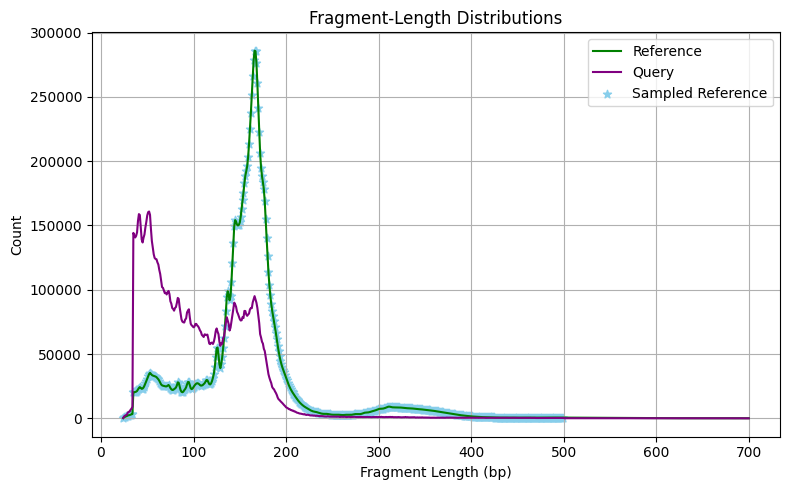

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(reference_df['Length'], reference_df['Frequency'], label='Reference', color='green')
plt.plot(query_df['Length'], query_df['Frequency'], label='Query', color='purple')
plt.scatter(sampled_reference_df['Length'],
            sampled_reference_df['Frequency'],
            marker='*', label='Sampled Reference', color='skyblue')
plt.title('Fragment-Length Distributions')
plt.xlabel('Fragment Length (bp)')
plt.ylabel('Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
